## Q1. Load the bank.csv dataset into your environment and inspect the first few rows.

In [ ]:
import pandas as pd

In [ ]:
# Read dataset

bank_data = pd.read_csv("/content/drive/MyDrive/capstone project /ml engineer/Banking_Distributed_ML_Project/bank.csv")
bank_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [ ]:
# Clean column names
bank_data.columns = bank_data.columns.str.strip()
bank_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

**Conclusion**

The dataset was imported successfully into a Pandas DataFrame.
Viewing the first few rows confirmed that the records were loaded
correctly, while checking the column names ensured that all fields
were available for analysis. This step verifies data readiness
before performing any transformations or calculations.

## Q2. Average Account Balance by Job. Write a MapReduce program in Python that calculates the average account balance for each job type.


In [ ]:
# Calculate mean balance by occupation
job_balance_summary = (bank_data.groupby("job")["balance"].mean().reset_index())


In [ ]:
# Round values
job_balance_summary["balance"] = job_balance_summary["balance"].round(2)

# Display results
job_balance_summary.sort_values(by="balance",ascending=False)

,job,balance
5,retired,2319.19
3,housemaid,2083.80
4,management,1766.93
2,entrepreneur,1645.12
8,student,1543.82
11,unknown,1501.71
6,self-employed,1392.41
9,technician,1331.00
0,admin.,1226.74
7,services,1103.96


**Conclusion**

The analysis calculated the average account balance for
each occupation category. Retired customers recorded the
highest average balances, whereas blue-collar workers had
comparatively lower balances. These results help identify
customer groups with stronger financial positions.

## Q3 Write a MapReduce program that counts the number of individuals with and without a housing loan in each education category.

In [ ]:
## Count customers by education and housing status
education_housing_summary = (bank_data.groupby(["education", "housing"]).size().reset_index(name="total_count"))

education_housing_summary.sort_values(by="education")

,education,housing,total_count
0,primary,no,295
1,primary,yes,383
2,secondary,no,876
3,secondary,yes,1430
4,tertiary,no,687
5,tertiary,yes,663
6,unknown,no,104
7,unknown,yes,83


**Conclusion**

Grouping customers by education and housing loan status
provided a clear breakdown of loan ownership across
educational backgrounds. This summary helps evaluate
how housing loan distribution differs among education
categories.

## Q4. Perform a MapReduce job to determine the number of clients contacted in each month and their subscription status to term deposits ('y' column).

In [ ]:
## Count contacts by month and subscription result

monthly_subscription_summary = (bank_data.groupby(["month", "y"]).size().reset_index(name="client_count"))

monthly_subscription_summary.sort_values(by="month")

,month,y,client_count
0,apr,no,237
1,apr,yes,56
2,aug,no,554
3,aug,yes,79
4,dec,no,11
5,dec,yes,9
6,feb,no,184
7,feb,yes,38
8,jan,no,132
9,jan,yes,16


**Conclusion**

The monthly contact analysis shows how many customers
were reached during each month and whether they
subscribed to a term deposit. Such information can be
used to evaluate seasonal campaign effectiveness and
customer response patterns.

## Q5. Analyze the average duration of contact (in seconds) per campaign outcome (poutcome).

In [ ]:
## Average call duration by campaign outcome

campaign_duration = (bank_data.groupby("poutcome")["duration"].mean().reset_index())

campaign_duration["duration"] = (campaign_duration["duration"].round(2))

campaign_duration

,poutcome,duration
0,failure,254.38
1,other,273.83
2,success,338.64
3,unknown,262.10


**Conclusion**

Customers associated with successful previous campaign
outcomes generally had longer contact durations.
Comparing average durations across outcomes helps
identify engagement levels and customer responsiveness.

## Q6. Examine the relationship between the age of clients and their balance, and present findings in a summarized form.

In [ ]:
## Descriptive statistics
age_balance_stats = (bank_data[["age", "balance"]].describe())

In [ ]:
# Correlation matrix
age_balance_relationship = (bank_data[["age", "balance"]].corr())

In [ ]:
age_balance_stats, age_balance_relationship

(               age       balance
 count  4521.000000   4521.000000
 mean     41.170095   1422.657819
 std      10.576211   3009.638142
 min      19.000000  -3313.000000
 25%      33.000000     69.000000
 50%      39.000000    444.000000
 75%      49.000000   1480.000000
 max      87.000000  71188.000000,
              age  balance
 age      1.00000  0.08382
 balance  0.08382  1.00000)

**Conclusion**

Summary statistics provide an overview of age and
account balance distributions. Correlation analysis
indicates that the relationship between age and balance
is relatively weak, suggesting that age alone does not
strongly explain variations in customer balances.

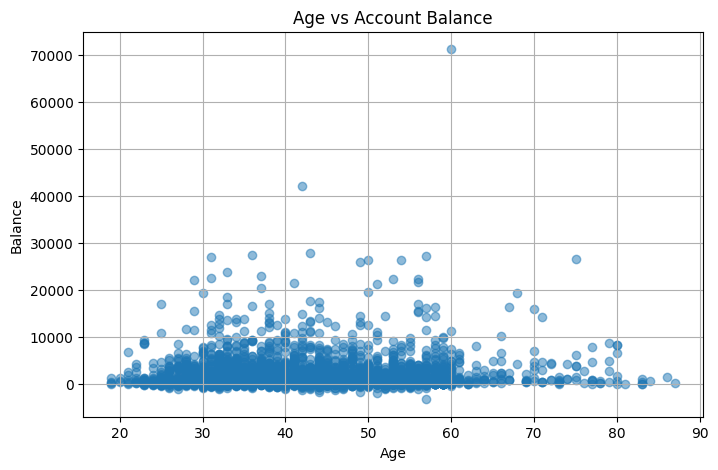

In [ ]:
## Scatter Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(
bank_data["age"],
bank_data["balance"],
alpha=0.5
)

plt.title("Age vs Account Balance")
plt.xlabel("Age")
plt.ylabel("Balance")
plt.grid(True)
plt.show()

# **Hive**

## Q7. Count Total Number of Clients

In [ ]:
## Calculate total records

client_count = bank_data.shape[0]

print("Total number of clients:", client_count)

Total number of clients: 4521


**Conclusion**

By counting the rows in the dataset, the total number
of clients was determined. Since each record represents
an individual customer, this value reflects the overall
dataset size available for analysis.

## Q8. Display the First 10 Rows of the Dataset.

In [ ]:
# Show first ten records

bank_data.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


**Conclusion**

Displaying the first ten records provides a quick
overview of the dataset structure, available features,
and sample values. This is useful for verifying data
quality and understanding the information collected
for each customer.

## Q9. Retrieve records of married clients who have a personal loan.

In [ ]:
# Filter married customers with personal loans

married_loan_clients = bank_data[(bank_data["marital"] == "married") & (bank_data["loan"] == "yes")]

married_loan_clients.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no
14,31,blue-collar,married,secondary,no,360,yes,yes,cellular,29,jan,89,1,241,1,failure,no
15,40,management,married,tertiary,no,194,no,yes,cellular,29,aug,189,2,-1,0,unknown,no
28,56,self-employed,married,secondary,no,784,no,yes,cellular,30,jul,149,2,-1,0,unknown,no
29,53,admin.,married,secondary,no,105,no,yes,cellular,21,aug,74,2,-1,0,unknown,no
56,57,management,married,secondary,no,82,no,yes,telephone,4,feb,140,1,-1,0,unknown,no
60,41,blue-collar,married,primary,no,-516,no,yes,telephone,8,jul,554,3,-1,0,unknown,no
68,41,management,married,secondary,no,0,no,yes,cellular,7,jul,630,3,-1,0,unknown,no


**Conclusion**

Filtering based on marital status and loan ownership
identified married customers who currently hold a
personal loan. This subset can be useful for targeted
customer analysis and financial product evaluation.

## Q10. Top 10 Clients with Highest Balance
List the top 10 clients with the highest balance, displaying their job, marital status, and balance.

In [ ]:
# Sort customers by balance in descending order

highest_balance_clients = (bank_data.sort_values(by="balance",ascending=False)[["job", "marital", "balance"]].head(10))
highest_balance_clients

,job,marital,balance
3700,retired,married,71188
2989,entrepreneur,married,42045
1483,technician,single,27733
1881,management,married,27359
3830,technician,married,27069
871,housemaid,single,26965
4047,retired,married,26452
3011,services,married,26394
2196,management,divorced,26306
1031,retired,single,25824


**Conclusion**

The dataset was sorted according to account balance to
identify customers with the largest balances. Reviewing
these records helps highlight high-value customers and
provides insight into the occupations and marital
categories associated with larger account holdings.

## Q11. Average Age of Clients by Job
Calculate the average age of clients for each job category.

In [ ]:
# Compute average age by occupation
job_age_summary = (bank_data.groupby("job")["age"].mean().reset_index())

#Round values

job_age_summary["age"] = (job_age_summary["age"].round(2))

#Display results

job_age_summary.sort_values(by="age",ascending=False)

,job,age
5,retired,61.87
11,unknown,48.11
3,housemaid,47.34
2,entrepreneur,42.01
6,self-employed,41.45
10,unemployed,40.91
4,management,40.54
1,blue-collar,40.16
0,admin.,39.68
9,technician,39.47


**Conclusion**

The average age was calculated for each occupation group.
Retired customers naturally showed the highest average age,
while students represented the youngest category. This
analysis provides demographic insights across professions.

## Q12. Credit Default by Education Level
Find the total number of clients for each education level who have defaulted on credit.

In [ ]:
# Select only defaulted customers
credit_default_df = (bank_data[bank_data["default"] == "yes"])

In [ ]:
# Count defaults by education
education_default_summary = (credit_default_df.groupby("education").size().reset_index(name="default_count"))

In [ ]:
#Display results
education_default_summary.sort_values(by="default_count",ascending=False)


,education,default_count
1,secondary,46
2,tertiary,17
0,primary,10
3,unknown,3


**Conclusion**

The analysis focused on customers with recorded credit
defaults and grouped them according to education level.
This helps identify which educational categories account
for a larger share of default cases within the dataset.

## Q13. Top 5 Job Categories by Average Balance and Subscription Rate
Identify the top 5 job categories with the highest average balance and the percentage of clients in each of these job categories who have subscribed to a term deposit.

In [ ]:
# Average balance by job
avg_balance_job = (bank_data.groupby("job")["balance"].mean().reset_index(name="average_balance"))

In [ ]:
#Select top five occupations
top_jobs = (
avg_balance_job.sort_values(
by="average_balance",
ascending=False).head(5))

In [ ]:
# Filter original dataset
selected_jobs = bank_data[
bank_data["job"].isin(top_jobs["job"])]

In [ ]:
## Calculate subscription percentage

job_subscription = (selected_jobs.groupby("job")["y"].value_counts(normalize=True).unstack().fillna(0))

job_subscription["subscription_rate(%)"] = (job_subscription["yes"] * 100).round(2)

In [ ]:
## Merge datasets
job_performance = pd.merge(top_jobs,job_subscription["subscription_rate(%)"],on="job")

job_performance.sort_values(by="average_balance",ascending=False)

,job,average_balance,subscription_rate(%)
0,retired,2319.191304,23.48
1,housemaid,2083.803571,12.50
2,management,1766.928793,13.52
3,entrepreneur,1645.125000,8.93
4,student,1543.821429,22.62


**Conclusion**

High-balance occupations were identified and compared
with their term deposit subscription rates. This analysis
helps determine whether financially stronger customer
groups are also more likely to subscribe to banking
investment products.

## Q14. Month with Highest Contacts and Campaign Success Rate
Determine the month with the highest number of contacts and the success rate of the campaign in that month.

In [ ]:
## Total contacts by month
monthly_contacts = (bank_data.groupby("month").size().reset_index(name="contact_count"))

## Successful subscriptions
monthly_success = (bank_data[bank_data["y"] == "yes"].groupby("month").size().reset_index(name="successful_subscriptions"))

## Merge results

campaign_result = pd.merge(monthly_contacts,monthly_success,on="month",how="left").fillna(0)

## Success percentage

campaign_result["success_rate(%)"] = (campaign_result["successful_subscriptions"] /campaign_result["contact_count"] * 100).round(2)

## Display result

campaign_result.sort_values(by="contact_count",ascending=False)

,month,contact_count,successful_subscriptions,success_rate(%)
8,may,1398,93,6.65
5,jul,706,61,8.64
1,aug,633,79,12.48
6,jun,531,55,10.36
9,nov,389,39,10.03
0,apr,293,56,19.11
3,feb,222,38,17.12
4,jan,148,16,10.81
10,oct,80,37,46.25
11,sep,52,17,32.69


**Conclusion**

This analysis combines contact volume with campaign
performance. Identifying the month with the largest
number of customer contacts and evaluating the related
success rate helps measure both outreach scale and
campaign effectiveness.

## Q15. Correlation Between Age and Balance
Calculate the correlation between age and balance for the clients.

In [ ]:
## Pearson correlation
age_balance_correlation = (bank_data["age"].corr(bank_data["balance"]))

print("Correlation between age and balance:",round(age_balance_correlation, 4))

Correlation between age and balance: 0.0838


**Conclusion**

The correlation coefficient indicates a very weak
positive association between age and account balance.
This suggests that age has limited influence on balance
levels and that other factors may contribute more
significantly to balance differences among customers.

## Q16. Year-over-Year Trend in Number of Clients Contacted
Analyze the year-over-year trend in the number of clients contacted.

In [ ]:
## Count contacts by month

contact_trend = (
bank_data["month"]
.value_counts()
.reset_index()
)

contact_trend.columns = [
"month",
"total_contacts"
]

## Sort alphabetically

contact_trend = (
contact_trend.sort_values(by="month")
)

## Display results

contact_trend

,month,total_contacts
5,apr,293
2,aug,633
11,dec,20
6,feb,222
7,jan,148
1,jul,706
3,jun,531
10,mar,49
0,may,1398
4,nov,389


**Conclusion**

Since yearly information is not available in the dataset,
monthly contact frequencies were analyzed instead. This
provides an overview of customer outreach activity and
helps identify periods with greater campaign intensity.

# Q17. Anomaly Detection – Average Balance by Education Level
Identify any unusual patterns in the average yearly balance across different education levels.

In [ ]:
## Average balance by education

education_balance = (
bank_data.groupby("education")["balance"].mean().reset_index()
)

## Round values

education_balance["balance"] = (education_balance["balance"].round(2))

## Display results

education_balance.sort_values(by="balance",ascending=False)

,education,balance
2,tertiary,1775.42
3,unknown,1701.25
0,primary,1411.54
1,secondary,1196.81


**Conclusion**

Comparing average balances across education groups
revealed noticeable differences. The unknown education
category displayed a relatively high average balance,
which may indicate data irregularities or a unique
customer segment deserving further investigation.

# Q18. Impact of Previous Campaign Outcome (poutcome) on Subscription and Contact Duration

Analyze the impact of previous campaign outcomes (poutcome) on the current campaign's success. Calculate the subscription rate and average contact duration for each poutcome category.

In [ ]:
#Group records by campaign outcome

campaign_group = (bank_data.groupby("poutcome"))

#Subscription percentage

campaign_subscription = (campaign_group["y"].value_counts(normalize=True).unstack().fillna(0))

campaign_subscription["subscription_rate(%)"] = (campaign_subscription["yes"] * 100).round(2)

## Average duration

campaign_duration = (campaign_group["duration"].mean().round(2))

## Combine outputs

campaign_impact = pd.concat([
campaign_subscription["subscription_rate(%)"],
campaign_duration
],
axis=1
).reset_index()

campaign_impact.columns = [
"poutcome",
"subscription_rate(%)",
"average_duration(sec)"
]

## Display results

campaign_impact.sort_values(
by="subscription_rate(%)",
ascending=False
)

,poutcome,subscription_rate(%),average_duration(sec)
2,success,64.34,338.64
1,other,19.29,273.83
0,failure,12.86,254.38
3,unknown,9.10,262.10


**Conclusion**

Previous campaign performance appears to influence
current campaign outcomes. Customers associated with
earlier successful campaigns demonstrate considerably
higher subscription rates. In addition, successful
groups tend to have longer average contact durations,
suggesting stronger customer engagement and interest.